### Sentimental analysis

## Step 1 — Data Load

In [1]:
#Load your processed data
import pandas as pd

df_processed = pd.read_csv(
    "../data/processed/customer_reviews_processed.csv"
)

## Step 2 — Data extraction

In [2]:
#Define input and target

X = df_processed["clean_text"]
y = df_processed["sentiment"]

In [3]:
print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (34614,)
y shape: (34614,)


0    this product so far has not disappointed. my c...
1    great for beginner or experienced person. boug...
2    inexpensive tablet for him to use and learn on...
3    i've had my fire hd 8 two weeks now and i love...
4    i bought this for my grand daughter when she c...
Name: clean_text, dtype: str

In [4]:
y.head()
#X = review text ,y = answer we want the model to learn

0    positive
1    positive
2    positive
3    positive
4    positive
Name: sentiment, dtype: str

## Step 3 — Train/test split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
print("Training:", y_train.value_counts())
print()
print("Test:", y_test.value_counts())

Training: sentiment
positive    25844
neutral      1199
negative      648
Name: count, dtype: int64

Test: sentiment
positive    6461
neutral      300
negative     162
Name: count, dtype: int64


## Step 4 — TF-IDF

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

## Step 5 — Fit TF-IDF ONLY on training data

In [8]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [9]:
X_test_tfidf = vectorizer.transform(X_test)

In [10]:
print("Training shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Training shape: (27691, 10000)
Test shape: (6923, 10000)


## Step 6 :Define Baseline model 

# 1.Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [12]:
model.fit(
    X_train_tfidf,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [13]:
y_pred = model.predict(X_test_tfidf)
y_pred[:10]
y_test[:10].values

<ArrowStringArray>
['positive', 'positive', 'positive', 'positive', 'positive', 'positive',
 'positive', 'positive',  'neutral', 'positive']
Length: 10, dtype: str

In [14]:
##Accurancy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 86.00%


In [ ]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

In [ ]:
##Step 12 — Precision, Recall and F1
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

In [ ]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Macro F1: {macro_f1:.2%}")

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["negative", "neutral", "positive"]
)

cm

In [ ]:
## Visualizing confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Sentiment Confusion Matrix")
plt.show()

## Tune Logistic Regression

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Build the pipeline
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("lr", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [20]:
# Test only the most useful settings first
param_grid = {
    "tfidf__max_features": [10000, 20000],
    "tfidf__ngram_range": [(1, 2)],
    "tfidf__min_df": [2],
    "lr__C": [0.5, 1, 2],
    "lr__class_weight": ["balanced", None]
}

In [21]:

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lr__C': [0.5, 1, ...], 'lr__class_weight': ['balanced', None], 'tfidf__max_features': [10000, 20000], 'tfidf__min_df': [2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_gl

In [22]:
print("Best parameters:")
print(grid.best_params_)

Best parameters:
{'lr__C': 2, 'lr__class_weight': 'balanced', 'tfidf__max_features': 20000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}


In [23]:
print(
    f"Best CV Macro F1: "
    f"{grid.best_score_:.2%}"
)

Best CV Macro F1: 55.67%


In [24]:
best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)

In [25]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

print(classification_report(y_test, y_pred_tuned))

print(
    f"Accuracy: "
    f"{accuracy_score(y_test, y_pred_tuned):.2%}"
)

print(
    f"Macro F1: "
    f"{f1_score(y_test, y_pred_tuned, average='macro'):.2%}"
)

              precision    recall  f1-score   support

    negative       0.38      0.54      0.45       162
     neutral       0.21      0.39      0.27       300
    positive       0.97      0.92      0.95      6461

    accuracy                           0.89      6923
   macro avg       0.52      0.62      0.55      6923
weighted avg       0.93      0.89      0.91      6923

Accuracy: 88.96%
Macro F1: 55.47%


In [ ]:
#Accuracy-tuned Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("lr", LogisticRegression(
        max_iter=1500,
        random_state=42
    ))
])

param_grid = {
    "tfidf__max_features": [20000, 40000],
    "tfidf__ngram_range": [(1, 2), (1, 3)],
    "tfidf__min_df": [2],
    "tfidf__sublinear_tf": [True],
    "lr__C": [2, 5, 10],
    "lr__class_weight": [None, "balanced"]
}

grid_more = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="accuracy",  # Target this experiment: accuracy
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_more.fit(X_train, y_train)

print("Best parameters:", grid_more.best_params_)
print(f"Best CV accuracy: {grid_more.best_score_:.2%}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters: {'lr__C': 5, 'lr__class_weight': None, 'tfidf__max_features': 20000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}
Best CV accuracy: 93.72%


In [27]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import pandas as pd

# Get the best model from GridSearchCV
candidate_model = grid_more.best_estimator_

# Evaluate on the held-out test set
y_pred_candidate = candidate_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_candidate))

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_candidate):.2%}")

print(
    f"Test Macro F1: "
    f"{f1_score(y_test, y_pred_candidate, average='macro'):.2%}"
)

labels = ["negative", "neutral", "positive"]

cm = confusion_matrix(
    y_test,
    y_pred_candidate,
    labels=labels
)

display(pd.DataFrame(cm, index=labels, columns=labels))

Classification Report:
              precision    recall  f1-score   support

    negative       0.61      0.23      0.34       162
     neutral       0.43      0.10      0.16       300
    positive       0.95      0.99      0.97      6461

    accuracy                           0.94      6923
   macro avg       0.66      0.44      0.49      6923
weighted avg       0.92      0.94      0.92      6923

Test Accuracy: 93.77%
Test Macro F1: 49.04%


,negative,neutral,positive
negative,38,16,108
neutral,10,30,260
positive,14,23,6424


In [ ]:
#Import the tools needed for tuning
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

#Build a pipeline
# A pipeline keeps text conversion and classification together.
# It also ensures TF-IDF is fitted separately inside each CV training fold.

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ("lr", LogisticRegression(
        max_iter=1500,
        random_state=42
    ))
])
# Define the settings to compare
# C controls regularization:
# smaller C = stronger regularization; larger C = weaker regularization.
#
# class_weight changes how much importance each class receives.
# The custom dictionaries give extra weight to negative and neutral reviews,
# which are much less common than positive reviews.

param_grid = {
    "lr__C": [2, 5, 10],
    "lr__class_weight": [
        None,
        "balanced",
        {
            "negative": 2.0,
            "neutral": 1.5,
            "positive": 1.0
        },
        {
            "negative": 3.0,
            "neutral": 2.0,
            "positive": 1.0
        }
    ]
}

# Run GridSearchCV
# 3 values of C x 4 class-weight options = 12 combinations.
# With 3-fold CV, this means 12 x 3 = 36 model fits.
#
# Macro F1 gives equal importance to negative, neutral and positive.
# refit=True is the default: after choosing the best settings,
# GridSearchCV fits the selected pipeline on all of X_train.

weight_grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

weight_grid.fit(X_train, y_train)

print("Best parameters:", weight_grid.best_params_)
print(f"Best CV Macro F1: {weight_grid.best_score_:.2%}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'lr__C': 5, 'lr__class_weight': 'balanced'}
Best CV Macro F1: 56.01%


In [29]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

weight_model = weight_grid.best_estimator_
y_pred_weight = weight_model.predict(X_test)

print(classification_report(y_test, y_pred_weight))
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_weight):.2%}")
print(f"Test Macro F1: {f1_score(y_test, y_pred_weight, average='macro'):.2%}")

              precision    recall  f1-score   support

    negative       0.41      0.52      0.46       162
     neutral       0.22      0.35      0.27       300
    positive       0.97      0.94      0.95      6461

    accuracy                           0.90      6923
   macro avg       0.53      0.60      0.56      6923
weighted avg       0.92      0.90      0.91      6923

Test Accuracy: 90.13%
Test Macro F1: 56.18%


## 2.Multinomial Naive Bayes

In [ ]:
#Train Naive Bayes

from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()

In [20]:
nb_model.fit(
    X_train_tfidf,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[ 648., 1199.,25844.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-3.75,-3.14,-0.07]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U8](3,)","['negative','neutral','positive']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 10000)","[[ 0.17, 1.59, 0. ,..., 0. , 0. , 0.19], [ 0.53, 1.78, 0.28,..., 0.2 , 0. , 0. ], [10.55,33.85, 2.4 ,..., 5.21, 3.3 , 2.84]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 10000)","[[ -9.39, -8.6 , -9.55,..., -9.55, -9.55, -9.38], [ -9.31, -8.72, -9.49,..., -9.56, -9.74, -9.74], [ -9.48, -8.37,-10.7 ,...,-10.1 ,-10.46,-10.58]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10000


In [21]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       162
     neutral       0.00      0.00      0.00       300
    positive       0.93      1.00      0.97      6461

    accuracy                           0.93      6923
   macro avg       0.31      0.33      0.32      6923
weighted avg       0.87      0.93      0.90      6923



/home/haripriya/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/haripriya/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/haripriya/anaconda3/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [23]:
from sklearn.metrics import accuracy_score, f1_score

nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

nb_macro_f1 = f1_score(
    y_test,
    y_pred_nb,
    average="macro"
)

print(f"Naive Bayes Accuracy: {nb_accuracy:.2%}")
print(f"Naive Bayes Macro F1: {nb_macro_f1:.2%}")

Naive Bayes Accuracy: 93.33%
Naive Bayes Macro F1: 32.19%


## 3.Linear SVM

In [ ]:
#Train LinearSVC
from sklearn.svm import LinearSVC
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)
svm_model.fit(
    X_train_tfidf,
    y_train
)
y_pred_svm = svm_model.predict(
    X_test_tfidf
)
print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

    negative       0.51      0.38      0.43       162
     neutral       0.29      0.27      0.28       300
    positive       0.96      0.97      0.96      6461

    accuracy                           0.92      6923
   macro avg       0.59      0.54      0.56      6923
weighted avg       0.92      0.92      0.92      6923



In [25]:
svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

svm_macro_f1 = f1_score(
    y_test,
    y_pred_svm,
    average="macro"
)

print(f"SVM Accuracy: {svm_accuracy:.2%}")
print(f"SVM Macro F1: {svm_macro_f1:.2%}")

SVM Accuracy: 92.47%
SVM Macro F1: 56.02%


In [26]:
## confusion matrix of svm model
from sklearn.metrics import confusion_matrix
import pandas as pd

labels = ["negative", "neutral", "positive"]

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=labels
)

cm_svm_df = pd.DataFrame(
    cm_svm,
    index=labels,
    columns=labels
)

cm_svm_df

,negative,neutral,positive
negative,61,33,68
neutral,22,82,196
positive,36,166,6259


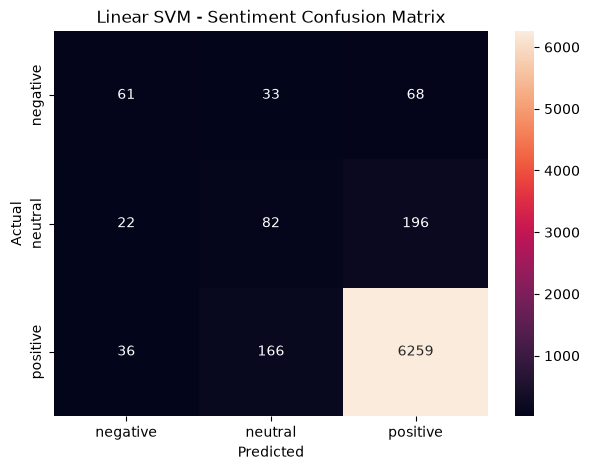

In [ ]:
#Plot Linear SVM Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_svm_df,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear SVM - Sentiment Confusion Matrix")

plt.show()

In [ ]:
#Cross-validate 3 TF-IDF classifiers (LogReg, Linear SVM, Calibrated SVM)
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.calibration import CalibratedClassifierCV

def tfidf():
    return TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

candidates = {
    "Logistic Regression": make_pipeline(
        tfidf(), LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    "Linear SVM": make_pipeline(
        tfidf(), LinearSVC(class_weight="balanced", random_state=42)),
    "Calibrated SVM": make_pipeline(
        tfidf(), CalibratedClassifierCV(LinearSVC(class_weight="balanced", random_state=42), cv=5)),
}

for name, m in candidates.items():
    s = cross_val_score(m, X_train, y_train, cv=5, scoring="f1_macro")
    print(f"{name}: macro F1 {s.mean():.3f} +/- {s.std():.3f}")

Logistic Regression: macro F1 0.538 +/- 0.009
Linear SVM: macro F1 0.551 +/- 0.010
Calibrated SVM: macro F1 0.467 +/- 0.018


## Conclusion

Approximately 93% of the reviews are positive, making accuracy alone a misleading evaluation metric. I therefore compared the models using macro F1, which gives equal importance to negative, neutral and positive sentiment classes.

| Model                                      | Test Accuracy | Test Macro F1 | Negative F1 | Neutral F1 | Positive F1 |   5-fold CV Macro F1 |
| ------------------------------------------ | ------------: | ------------: | ----------: | ---------: | ----------: | -------------------: |
| Multinomial Naive Bayes                    |        93.33% |        32.19% |        0.00 |       0.00 |        0.97 |              Not run |
| Baseline Logistic Regression               |        85.95% |        53.97% |        0.44 |       0.25 |        0.93 |        0.534 ± 0.008 |
| Linear SVM                                 |        92.19% |        54.83% |        0.42 |       0.27 |        0.96 |        0.550 ± 0.016 |
| Accuracy-tuned Logistic Regression         |        93.77% |        49.04% |        0.34 |       0.16 |        0.97 |         Not recorded |
| **Class-weight-tuned Logistic Regression** |    **90.13%** |    **56.18%** |    **0.46** |   **0.27** |    **0.95** | See tuning CV result |

### Final model: Class-weight-tuned Logistic Regression

* **Multinomial Naive Bayes:** Rejected because it did not identify negative or neutral reviews, despite its high accuracy.
* **Linear SVM:** Achieved a strong macro F1 score and performed well in cross-validation. However, `LinearSVC` does not provide class probabilities directly; obtaining them requires additional calibration.
* **Accuracy-tuned Logistic Regression:** Achieved the highest test accuracy at 93.77%, but its macro F1 was lower at 49.04%. It performed poorly on negative and neutral reviews.
* **Class-weight-tuned Logistic Regression:** Selected as the preferred model because it achieved the highest reported test macro F1 of 56.18%, with 90.13% accuracy. Custom class weights improved detection of negative and neutral reviews while maintaining strong performance on positive reviews.

The final model uses a TF-IDF vectorizer and Logistic Regression in a single pipeline. The pipeline is saved as `models/sentiment_pipeline.pkl` for use in the Streamlit demo, where users can submit review text and view the predicted sentiment and class probability scores.

**Limitation:** Neutral sentiment remains difficult to identify, with an F1-score of 0.27. The results should therefore be interpreted with the class imbalance in mind. Since the test set was used across several tuning experiments, the reported test scores are exploratory rather than a fully independent final estimate.


## Step 7: Select final model

In [30]:
# STEP 1: Import the tools needed for tuning

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# STEP 2: Build a pipeline
# A pipeline keeps text conversion and classification together.
# It also ensures TF-IDF is fitted separately inside each CV training fold.

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,  # Keep up to 20,000 useful word features
        ngram_range=(1, 2),  # Learn single words and two-word phrases
        min_df=2,            # Ignore terms appearing in fewer than 2 documents
        sublinear_tf=True    # Reduce the effect of repeated words
    )),
    ("lr", LogisticRegression(
        max_iter=1500,       # Allow more iterations for convergence
        random_state=42
    ))
])

# STEP 3: Define the settings to compare
# C controls regularization:
# smaller C = stronger regularization; larger C = weaker regularization.
#
# class_weight changes how much importance each class receives.
# The custom dictionaries give extra weight to negative and neutral reviews,
# which are much less common than positive reviews.

param_grid = {
    "lr__C": [2, 5, 10],
    "lr__class_weight": [
        None,
        "balanced",
        {
            "negative": 2.0,
            "neutral": 1.5,
            "positive": 1.0
        },
        {
            "negative": 3.0,
            "neutral": 2.0,
            "positive": 1.0
        }
    ]
}

# STEP 4: Run GridSearchCV
# 3 values of C x 4 class-weight options = 12 combinations.
# With 3-fold CV, this means 12 x 3 = 36 model fits.
#
# Macro F1 gives equal importance to negative, neutral and positive.
# refit=True is the default: after choosing the best settings,
# GridSearchCV fits the selected pipeline on all of X_train.

weight_grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1,
    refit=True
)

weight_grid.fit(X_train, y_train)

# STEP 5: Review the winning settings and CV result

print("Best parameters:")
print(weight_grid.best_params_)

print(f"Best CV Macro F1: {weight_grid.best_score_:.2%}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters:
{'lr__C': 5, 'lr__class_weight': 'balanced'}
Best CV Macro F1: 56.01%


In [31]:
# STEP 6: Select the best tuned pipeline as the final candidate

final_model = weight_grid.best_estimator_

# Confirm that we selected the tuned model
print(final_model)

# Check the classes the model can predict
print("Sentiment classes:", final_model.classes_)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('lr',
                 LogisticRegression(C=5, class_weight='balanced', max_iter=1500,
                                    random_state=42))])
Sentiment classes: ['negative' 'neutral' 'positive']


In [32]:
# STEP 7: Predict sentiments for the test reviews

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

y_pred_final = final_model.predict(X_test)

# Show precision, recall, F1-score and support for each class
print("Final Classification Report:")
print(classification_report(
    y_test,
    y_pred_final,
    labels=["negative", "neutral", "positive"],
    zero_division=0
))

# Calculate overall accuracy
final_accuracy = accuracy_score(y_test, y_pred_final)

# Calculate macro F1: the average F1 across the three classes
final_macro_f1 = f1_score(
    y_test,
    y_pred_final,
    labels=["negative", "neutral", "positive"],
    average="macro"
)

print(f"Final Test Accuracy: {final_accuracy:.2%}")
print(f"Final Test Macro F1: {final_macro_f1:.2%}")

Final Classification Report:
              precision    recall  f1-score   support

    negative       0.41      0.52      0.46       162
     neutral       0.22      0.35      0.27       300
    positive       0.97      0.94      0.95      6461

    accuracy                           0.90      6923
   macro avg       0.53      0.60      0.56      6923
weighted avg       0.92      0.90      0.91      6923

Final Test Accuracy: 90.13%
Final Test Macro F1: 56.18%


Final Confusion Matrix:


,negative,neutral,positive
negative,84,38,40
neutral,38,106,156
positive,82,329,6050


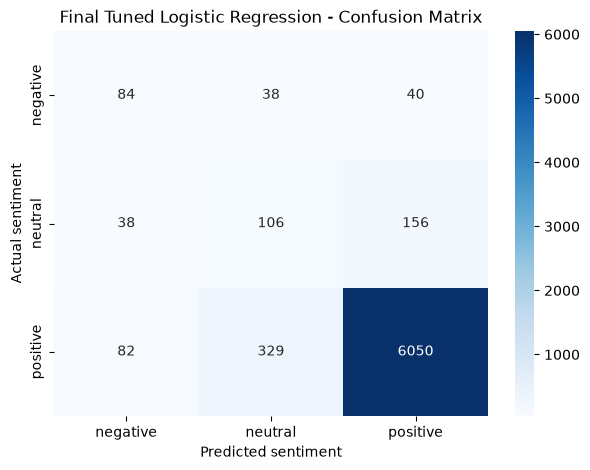

Confusion matrix saved to: ../reports/figures/cm_final_model.png


In [33]:
# STEP 8: Create the confusion matrix

from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

labels = ["negative", "neutral", "positive"]

cm_final = confusion_matrix(
    y_test,
    y_pred_final,
    labels=labels
)

# Display the counts as a readable table
cm_final_df = pd.DataFrame(
    cm_final,
    index=labels,
    columns=labels
)

print("Final Confusion Matrix:")
display(cm_final_df)

# STEP 9: Plot the confusion matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_final_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted sentiment")
plt.ylabel("Actual sentiment")
plt.title("Final Tuned Logistic Regression - Confusion Matrix")

# Create the reports/figures folder if it does not exist
figures_dir = Path("../reports/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# Save the figure for your project report or README
cm_path = figures_dir / "cm_final_model.png"

plt.savefig(
    cm_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(f"Confusion matrix saved to: {cm_path}")

## Step 8: save the final model

In [34]:
# STEP 10: Save the final tuned model

import joblib
import sklearn
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "sentiment_pipeline.pkl"

joblib.dump(final_model, model_path)

print("Final model saved successfully.")
print(f"Model path: {model_path}")
print(f"scikit-learn version: {sklearn.__version__}")
print("Classes:", final_model.classes_)

Final model saved successfully.
Model path: ../models/sentiment_pipeline.pkl
scikit-learn version: 1.9.0
Classes: ['negative' 'neutral' 'positive']
